## Imoporting Necessary Libraries

In [55]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import f1_score, classification_report, confusion_matrix,ConfusionMatrixDisplay
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import pickle 
import spacy

## Data processing to remove inconcistencies in the text data

In [3]:
class TextProcessing:
    def __init__(self, review):
        self.review=review
    def processing(self):
        with open(self.review, 'r', newline='') as f:
            reader = csv.DictReader(f)
            with open('data.csv', 'w', newline='') as out_f:
                fieldnames = ['Country', 'Review Date', 'Review Title', 'Review Text', 'Rating']  
                writer = csv.DictWriter(out_f, fieldnames=fieldnames)
                writer.writeheader()
                for row in reader:
                    writer.writerow({
                        'Country': row['Country'],
                        'Review Date': row['Review Date'],
                        'Review Title': row['Review Title'],
                        'Review Text' : row['Review Text'],
                        'Rating': row['Rating']
                })
        df = pd.read_csv('data.csv', parse_dates=['Review Date'],on_bad_lines='skip')
        df.dropna(inplace=True)
        df.drop_duplicates(inplace=True)
        #df['Rating'].str.split()
        df['Num_Rating']=df['Rating'].apply(lambda x:'POSITIVE' if int(x[6])>=4 else 'NEUTRAL' if int(x[6])==3 else 'NEGATIVE') #if int(x)<3)
        df['Review Date']= df['Review Date'].dt.year
        return df
    def Graph(self):
        df=self.processing()
        fg=df[df['Review Date']>2015]
        df.head()
        df['Num_Rating'].value_counts().plot(kind='bar', color='g')
        df[['Review Date','Num_Rating']] .value_counts()

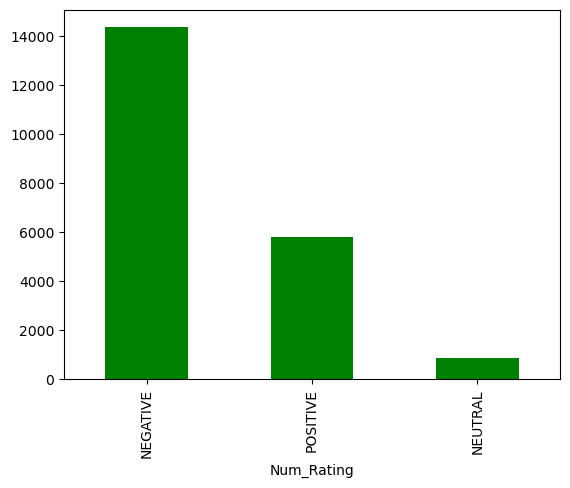

In [6]:
data_ = TextProcessing('Amazon_Reviews.csv')
data_.Graph()

## Feature Extraction

In [18]:
data=data_.processing()
data['num_rate']=data['Num_Rating'].map({'POSITIVE':1.0, 'NEUTRAL':0.0,'NEGATIVE':0.0})
X,y= data['Review Text'].values ,data['num_rate'].values
Xtrain, Xtest,ytrain,ytest = train_test_split(X, y, test_size=0.1,random_state=42, shuffle=True)
ytrain[:100].dtype

dtype('float64')

In [ ]:
!pip install -U spacy
!python -m spacy download en_core_web_sm

In [10]:
nlp=spacy.load('en_core_web_sm') # Function to clean and process the data for training
def lemma(text):
    doc=nlp(''.join(text))
    tok=[token.lemma_ for token in doc if not token.is_punct and not token.is_stop]
    return ' '.join(tok)

In [ ]:
data['text_xtract']=data['Review Text'].apply(lemma)


In [16]:
print(data.text_xtract.str.len().sum())
data.num_rate.value_counts(normalize=True)  #Checking to see how unbalanced is the dataset

5116698


num_rate
0.0    0.723615
1.0    0.276385
Name: proportion, dtype: float64

## Model Train

In [ ]:
#Model train
pipe=Pipeline([('scalar', TfidfVectorizer()), ('clf', RandomForestClassifier())])

param_grid= [
            {'clf': [KNeighborsClassifier()]},
            {'clf': [SVC()]},
            {'clf': [RandomForestClassifier()]}
            ]
grid= GridSearchCV(estimator=pipe, 
                   param_grid=param_grid,           
                   cv=5,
                   scoring= make_scorer(f1_score, average='macro'),
                   refit = True
                      )
#grid.fit(Xtrain, ytrain)

In [19]:
pipe=Pipeline([('transformer',TfidfVectorizer()),
               ('model', LinearSVC())
              ]
             )
params = [
    {
        'model': [LinearSVC()],
        'model__C': np.linspace(0.5, 2, 6),
        'model__class_weight': [{0: 1, 1: v} for v in range(1, 6)]
    },
    {
        'model': [LogisticRegression(max_iter=1000)],
        'model__C': np.linspace(0.5, 2, 6),
        'model__class_weight': [{0: 1, 1: v} for v in range(1, 6)]
    }
    ]
grid= GridSearchCV(pipe,
                 param_grid=params,
                 cv=5,
                 #scoring='f1',
                 refit=True
                 )

In [20]:
mod= grid.fit(Xtrain, ytrain)

In [23]:
print(f' best training score: {mod.best_score_},\n best parameters: {mod.best_params_}')
mod.best_estimator_

 best training score: 0.9316551105094527,
 best parameters: {'model': LinearSVC(), 'model__C': np.float64(0.5), 'model__class_weight': {0: 1, 1: 2}}


,steps,"[('transformer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


## Model Evaluation

In [41]:
y_pred=grid.predict(Xtest)
score=f1_score(y_pred, ytest)
score

0.8623063683304647

<Figure size 500x500 with 0 Axes>

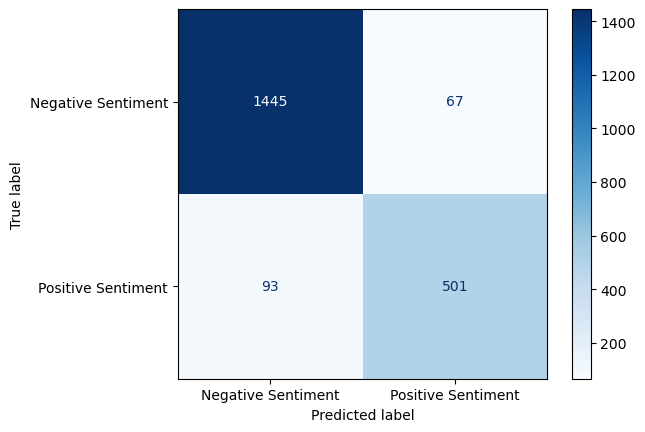

In [67]:
cm=confusion_matrix(y_pred, ytest)
disp=ConfusionMatrixDisplay(cm, display_labels=["Negative Sentiment","Positive Sentiment"])
plt.figure(figsize=(5,5))
disp.plot(cmap=plt.cm.Blues)
plt.show()

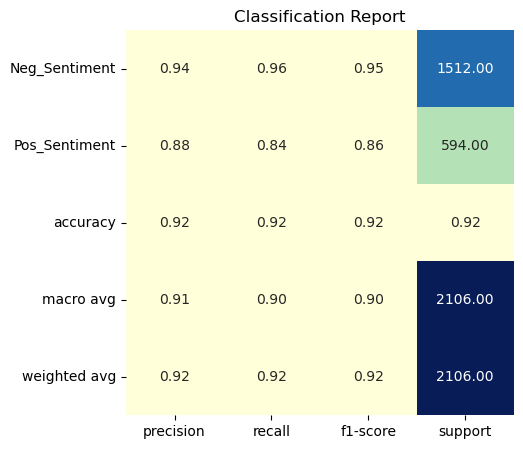

In [77]:
output=classification_report(y_pred, ytest ,output_dict=True )
to_frame=pd.DataFrame(output).transpose()
to_frame.index=['Neg_Sentiment', 'Pos_Sentiment', 'accuracy', 'macro avg', 'weighted avg']
plt.figure(figsize=(5,5))
sns.heatmap(to_frame,annot=True,
            cmap='YlGnBu',fmt='.2f',cbar=False)
plt.title('Classification Report')
plt.show()

In [71]:
to_frame.index

Index(['0.0', '1.0', 'accuracy', 'macro avg', 'weighted avg'], dtype='object')

In [35]:
y=lambda x: 'Postive Sentiment' if mod.predict(x)==1.0 else 'Negative Sentiment'

In [60]:
y([r"i can not recommend this"])
#mod.predict([r"i can not recommend this"])

'Negative Sentiment'

## Model Deployment

In [59]:
with open('fitted', 'wb') as model:
    pickle.dump(mod, model)


def prediction(text):
    with open('fitted', 'rb') as model:
        model=pickle.load(model)
        print('Positive Sentiment') if model.best_estimator_.predict(text)==1 else print('Negative Sentiment') 

In [ ]:
pipe=[Pipeline([('scaler',TfidfVectorizer()),
      ('model', KNeighborsClassifier())]),
      Pipeline([('scaler', TfidfVectorizer()),
      ('model', SVC())]),
      Pipeline([('scaler', CountVectorizer()),
      ('model', RandomForestClassifier())])
      ]
param_grid= [
             {'model__n_neighbors': np.arange(5,20)},
             {'model__class_weight': [{0:1, 1:v} for v in range(1,10)]},
             {'model__max_depth': np.arange(10)}
            ]

for i in zip(pipe, param_grid):
  mod=GridSearchCV(estimator=i[0], param_grid=i[1], cv=5)
  mod.fit(Xtrain, ytrain)
  print(mod.best_params_)
  print(i[0], i[1])

In [24]:
mod.best_estimator_

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [43]:
yt=mod.predict(Xtest)
score=accuracy_score(yt, ytest)
score

0.731718898385565

In [ ]:
mod.

### Model Deployment

In [66]:
with open('model.pkl', 'wb') as f:
    pickle.dump(grid, f)

In [84]:
with open('model.pkl', 'rb') as f:
    model=pickle.load(f)
    y=lambda x: 'Postive Sentiment' if model.predict(x)==1 else 'Negative Sentiment'
    print(y(['not good value for my money']))

Negative Sentiment


In [20]:
voting = VotingClassifier(
    estimators=[
        ('lr', Pipeline([
            ('scaler', CountVectorizer()),
            ('lr', LogisticRegression())
        ])),

        ('svc', Pipeline([
            ('scaler', CountVectorizer()),
            ('svc', SVC())
        ])),

        ('dt', Pipeline([
            ('scaler', CountVectorizer()),
            ('dt', DecisionTreeClassifier())
        ])),

        ('knn', Pipeline([
            ('scaler', CountVectorizer()),
            ('knn', KNeighborsClassifier())
        ]))
    ],
    voting='soft')
#voting.fit(Xtrain, ytrain.ravel())
#y_pred = voting.predict(Xtest)
#print(confusion_matrix(ytest.ravel(), y_pred))
#print(classification_report(ytest.ravel(), y_pred))